# Telco Customer Churn — Exploratory Data Analysis

This notebook performs structured exploratory data analysis (EDA) on the Telco Customer Churn dataset.  
The goal is to understand data structure, identify data quality issues, and prepare the dataset for modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

## Dataset Overview

We begin by inspecting dataset dimensions, data types, and overall structure.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df["TotalCharges"].unique()[:20]

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str

## Investigating TotalCharges Data Type Issue

The `TotalCharges` column is stored as a string due to the presence of blank values.
We identify and inspect these rows before deciding how to handle them.

In [7]:
(df["TotalCharges"].str.strip() == "").sum()

np.int64(11)

In [8]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [9]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["TotalCharges"].dtype

dtype('float64')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Data Cleaning: TotalCharges

The `TotalCharges` column was initially stored as a string due to blank values. Blank entries were identified and replaced with `NaN`, then converted to numeric format.

Missing values were filled with 0 based on business logic, as customers with zero tenure should have zero total charges. The column is now correctly stored as a numeric type.

## Target Variable: Customer Churn Distribution

The dataset contains 7,043 customers, of which 1,869 (26.5%) have churned and 5,174 (73.5%) have retained service.

The target variable is moderately imbalanced, with approximately one quarter of customers classified as churned. This imbalance should be considered during model evaluation, particularly when selecting performance metrics (e.g., precision, recall, F1-score).

In [12]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


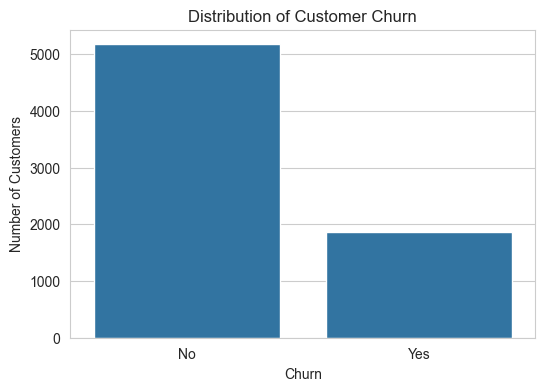

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df)
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

The dataset contains 7,043 customers, of which approximately 26.5% have churned.

The target variable is moderately imbalanced. This imbalance should be considered during model evaluation, particularly when selecting performance metrics such as precision, recall, and F1-score.

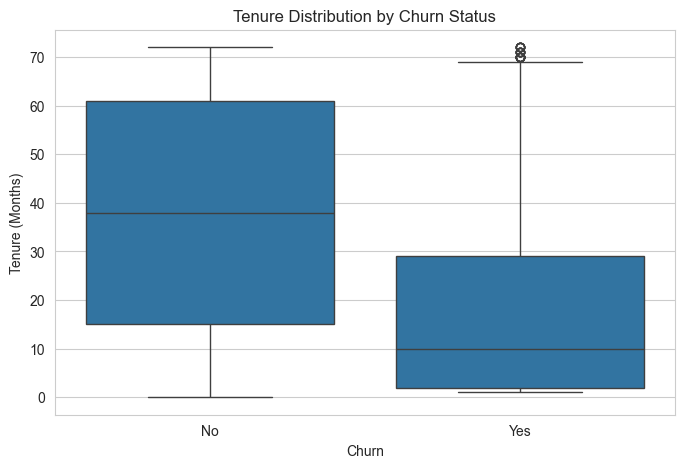

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

### Tenure and Churn

Customers who churn have significantly lower tenure compared to retained customers.

This suggests that churn risk is highest during the early stages of the customer lifecycle, and retention strategies may be most impactful within the first year.

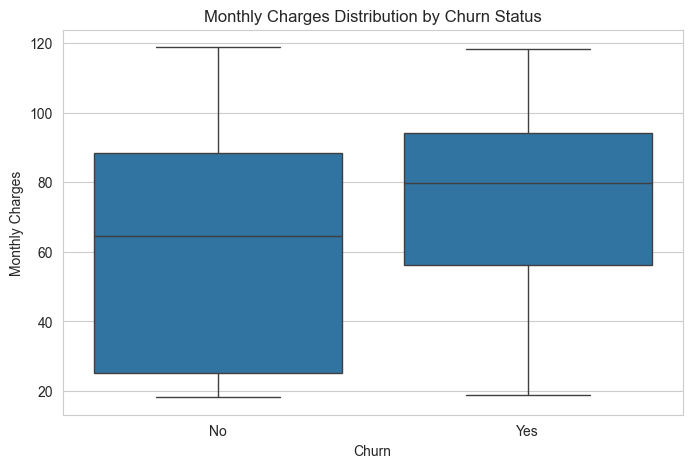

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

### Monthly Charges and Churn

Customers who churn tend to have higher monthly charges than those who remain.

Higher pricing may contribute to churn risk, particularly when combined with low tenure or month-to-month contracts.

In [16]:
contract_churn = (
    df.groupby("Contract")["Churn"]
      .value_counts(normalize=True)
      .unstack()
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


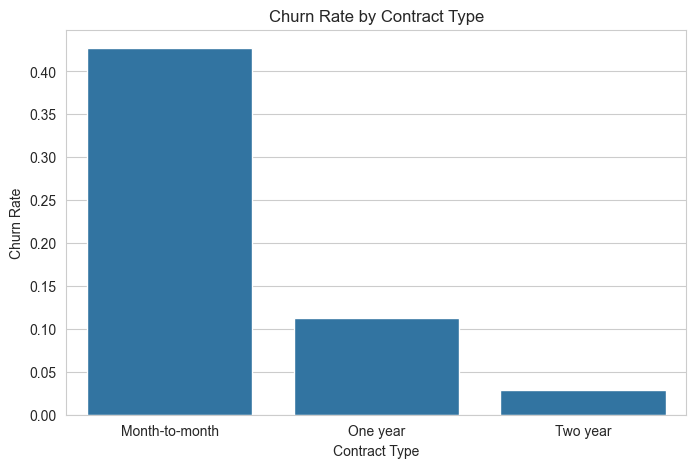

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(x=contract_churn.index,
            y=contract_churn["Yes"])
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.show()

### Contract Type and Churn

Month-to-month customers exhibit substantially higher churn rates compared to one-year and two-year contract customers.

Longer-term contracts are strongly associated with customer retention, suggesting commitment duration is a key churn driver.

In [18]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "12-24", "24-48", "48+"],
    include_lowest=True
)

tenure_churn = (
    df.groupby("tenure_group")["Churn"]
      .value_counts(normalize=True)
      .unstack()
)

tenure_churn

Churn,No,Yes
tenure_group,,
0-12,0.525618,0.474382
12-24,0.712891,0.287109
24-48,0.796110,0.203890
48+,0.904868,0.095132


### Interaction: Tenure and Contract

Within each tenure group, month-to-month customers consistently exhibit higher churn rates than customers on longer contracts.

This indicates that contract type has independent predictive power beyond tenure alone.

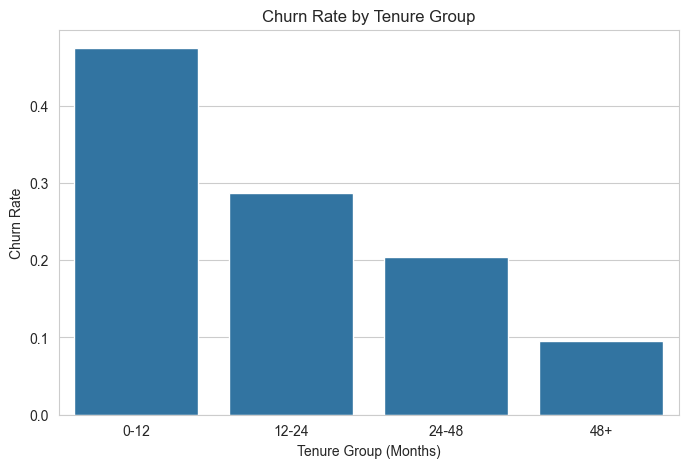

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(x=tenure_churn.index,
            y=tenure_churn["Yes"])
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Churn Rate")
plt.show()

In [20]:
tenure_contract_churn = (
    df.groupby(["tenure_group", "Contract"])["Churn"]
      .value_counts(normalize=True)
      .unstack()
)

tenure_contract_churn

Churn                              No       Yes
tenure_group Contract                          
0-12         Month-to-month  0.486459  0.513541
             One year        0.895161  0.104839
             Two year        1.000000       NaN
12-24        Month-to-month  0.622795  0.377205
             One year        0.918782  0.081218
             Two year        1.000000       NaN
24-48        Month-to-month  0.670823  0.329177
             One year        0.893822  0.106178
             Two year        0.978102  0.021898
48+          Month-to-month  0.739766  0.260234
             One year        0.870662  0.129338
             Two year        0.966746  0.033254

In [21]:
techsupport_churn = (
    df.groupby("TechSupport")["Churn"]
      .value_counts(normalize=True)
      .unstack()
)

techsupport_churn

Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


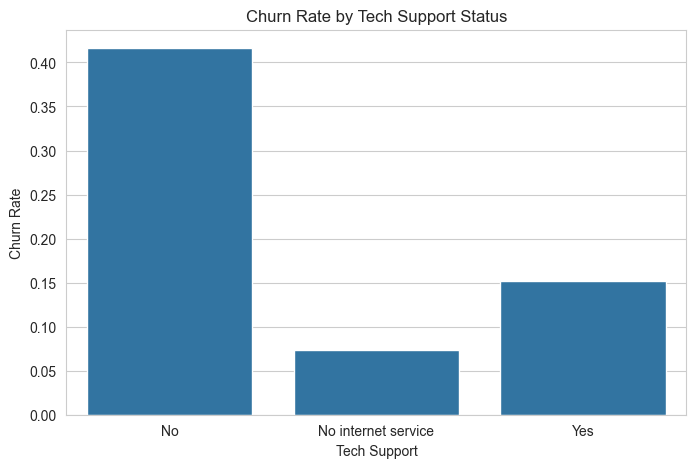

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(x=techsupport_churn.index,
            y=techsupport_churn["Yes"])
plt.title("Churn Rate by Tech Support Status")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate")
plt.show()

### Tech Support and Churn

Customers without tech support exhibit significantly higher churn rates compared to those with tech support.

Access to technical support appears to reduce churn risk, likely by mitigating service dissatisfaction.

In [23]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
      .value_counts(normalize=True)
      .unstack()
)

internet_churn

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


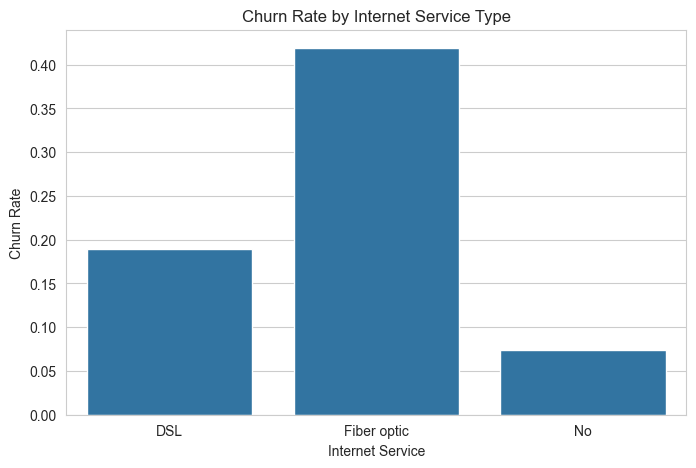

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(x=internet_churn.index,
            y=internet_churn["Yes"])
plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")
plt.show()


### Churn by Internet Service Type

Customers with fiber optic service exhibit the highest churn rate (~42%), significantly higher than DSL customers (~19%) and customers without internet service (~7%).

This suggests that fiber customers represent a high-risk segment, potentially due to higher pricing, service expectations, or dissatisfaction. Customers without internet service show the lowest churn, likely reflecting lower service complexity.

In [25]:
online_security_churn = (
    df.groupby("OnlineSecurity")["Churn"]
      .value_counts(normalize=True)
      .unstack()
)

online_security_churn

Churn,No,Yes
OnlineSecurity,,
No,0.582333,0.417667
No internet service,0.925950,0.074050
Yes,0.853888,0.146112


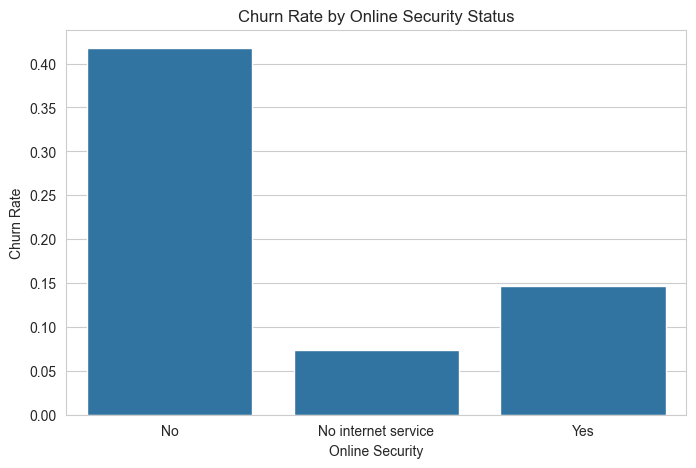

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(x=online_security_churn.index,
            y=online_security_churn["Yes"])
plt.title("Churn Rate by Online Security Status")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate")
plt.show()

In [27]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
      .value_counts(normalize=True)
      .unstack()
)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


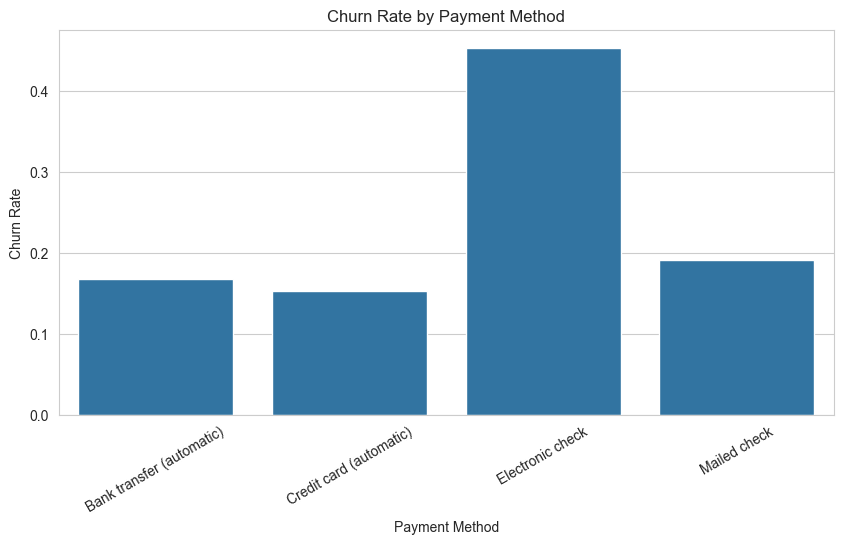

In [28]:
plt.figure(figsize=(10, 5))
sns.barplot(x=payment_churn.index,
            y=payment_churn["Yes"])
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=30)
plt.show()

### Online Security and Churn

Customers without online security services exhibit higher churn rates compared to those with security features.

Bundled service features may contribute to increased customer retention.

### Churn by Payment Method

Customers using electronic check exhibit the highest churn rate (~45%), significantly higher than customers using automatic payment methods (~15–17%).

Automatic payment methods (bank transfer and credit card) are associated with lower churn, suggesting that automated billing may improve customer retention. Electronic check users represent a high-risk behavioral segment.

In [29]:
paperless_churn = (
    df.groupby("PaperlessBilling")["Churn"]
      .value_counts(normalize=True)
      .unstack()
)

paperless_churn

Churn,No,Yes
PaperlessBilling,,
No,0.836699,0.163301
Yes,0.664349,0.335651


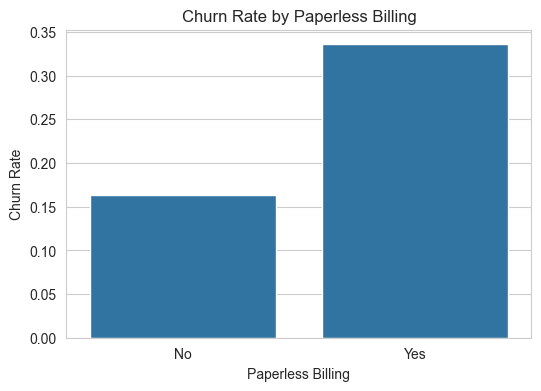

In [30]:
plt.figure(figsize=(6, 4))
sns.barplot(x=paperless_churn.index,
            y=paperless_churn["Yes"])
plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate")
plt.show()

### Paperless Billing and Churn

Customers enrolled in paperless billing show higher churn rates compared to those receiving paper statements.

This variable may correlate with other behavioral factors such as electronic check payments or month-to-month contracts.

## Exploratory Data Analysis Summary

Key findings from the analysis:

- Early-tenure customers exhibit the highest churn risk.
- Month-to-month contracts are strongly associated with churn.
- Fiber optic customers churn at significantly higher rates.
- Lack of tech support and online security are linked to increased churn.
- Electronic check users represent the highest-risk payment segment.

Overall, churn appears driven by a combination of:
- Low commitment (short contracts)
- Early lifecycle stage
- Service dissatisfaction
- Behavioral payment patterns

These insights will guide feature selection and modeling strategy in the next phase.